In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('amz_uk_price_prediction_dataset.csv')
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*

In [4]:
df['isBestSeller'].value_counts() 

isBestSeller
False    2435671
True        7980
Name: count, dtype: int64

In [5]:

crosstab = pd.crosstab(df['category'], df['isBestSeller'])
crosstab.columns = ['Not Best Seller', 'Best Seller']
crosstab['best_seller_percentage'] = crosstab['Best Seller'] / (crosstab['Best Seller'] + crosstab['Not Best Seller'])*100
crosstab = crosstab.sort_values('best_seller_percentage', ascending=False)
crosstab.head(10)

,Not Best Seller,Best Seller,best_seller_percentage
category,,,
Grocery,9008,556,5.813467
Smart Home Security & Lighting,98,6,5.769231
Health & Personal Care,9017,552,5.768628
Mobile Phone Accessories,248,11,4.247104
Power & Hand Tools,8353,306,3.533895
"Billiard, Snooker & Pool",241,8,3.212851
Pet Supplies,9152,285,3.020028
Home Brewing & Wine Making,239,7,2.845528
Wind Instruments,243,7,2.800000


Categorias como Grocery, Smart Home Security & Lighting y Health & Personal Care contiene mas productos considerados best seller que otras categorias pero sigue siendo en una proporcion baja

In [6]:
promedio_global = crosstab['best_seller_percentage'].mean()
print(f"Promedio global de Best Sellers: {promedio_global:.2f}%")


Promedio global de Best Sellers: 0.62%


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

In [7]:
from scipy.stats import chi2_contingency

# Chi-square test for 'category' and 'isBestSeller'
chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab[['Not Best Seller', 'Best Seller']])

print(f'Estadistico: {chi2_statistic}, Valor p: {chi2_p_value:.4e}')

Estadistico: 36540.20270061387, Valor p: 0.0000e+00


Se puede afirmar que la relacion entre la categoria y ser Best Seller no es casualidad (P-value < 0,05) hay una dependencia entre la variable categoria y si es best seller. 
Es decir, que un producto sea best seller o no depende fuertemente de la categoria a la que pertenece.  

In [8]:
from scipy.stats.contingency import association

# Computing the association between variables in 'crosstab' using the "cramer" method
association(crosstab[['Not Best Seller', 'Best Seller']], method="cramer")

0.1222829439760564

una v crames que este valor indica a su vez que aunque el valor p de chi sea 0 e indicque que existe una dependencia  entre ambas variables la fuerza de esta relacion es muy debil por lo que en la practica es despreciable 


3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

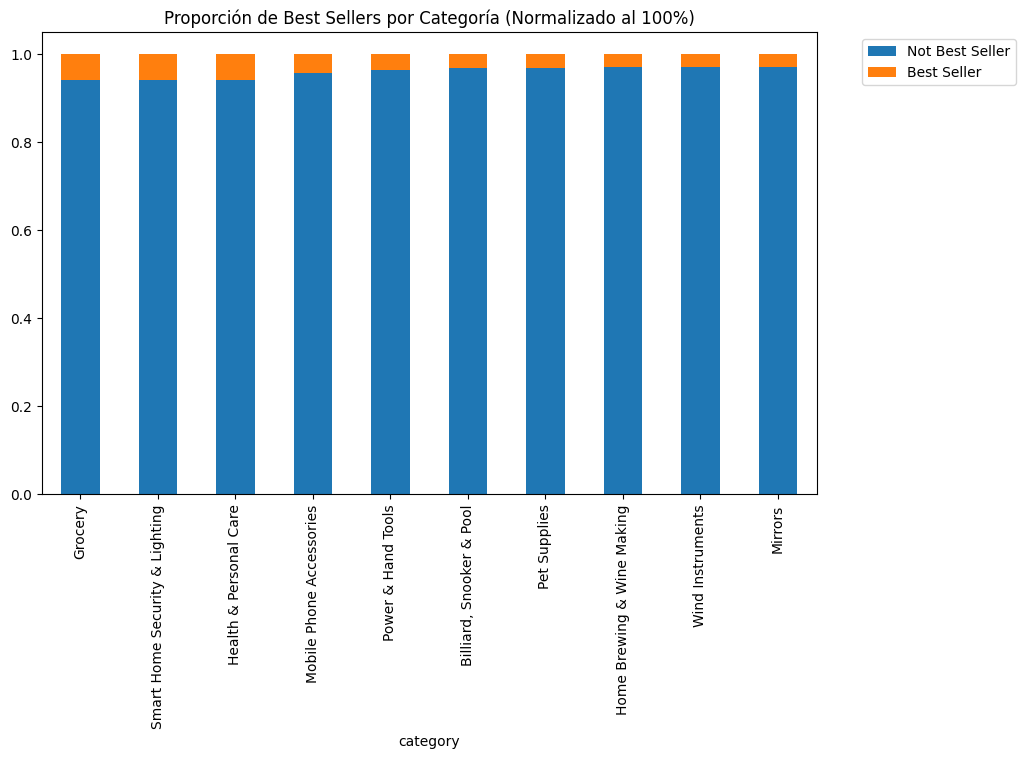

In [7]:
# Seleccionamos solo las columnas de conteo
df_counts = crosstab[['Not Best Seller', 'Best Seller']].head(10)

# Dividimos cada fila por su suma para obtener el 100%
df_perc = df_counts.div(df_counts.sum(axis=1), axis=0)

# Graficamos
df_perc.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Proporción de Best Sellers por Categoría (Normalizado al 100%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


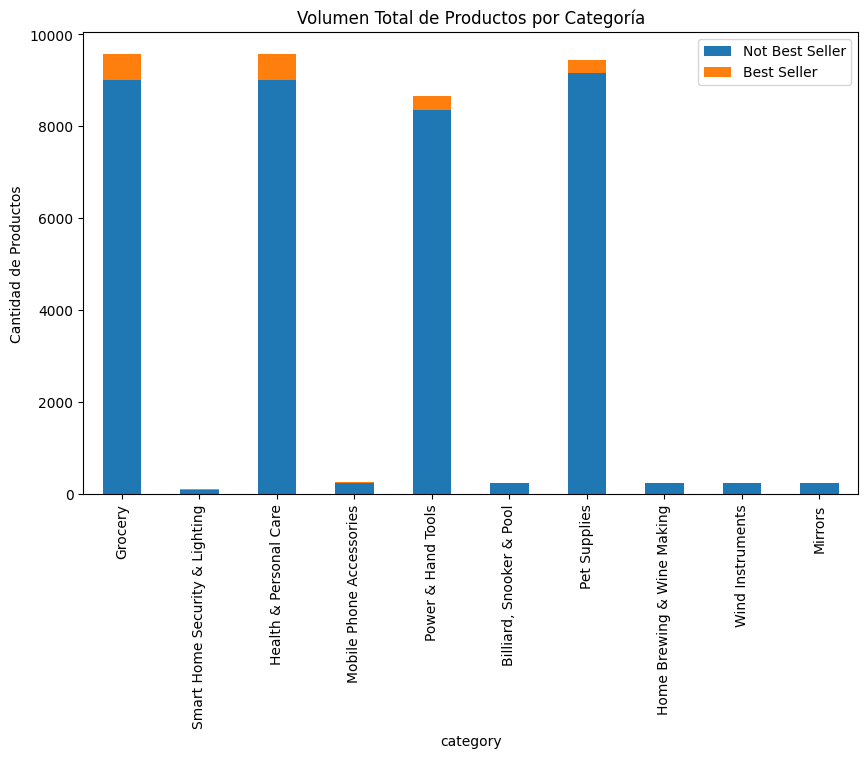

In [8]:
# Solo las columnas de conteo para que no se cuele el 'best_seller_percentage'
crosstab[['Not Best Seller', 'Best Seller']].head(10).plot(kind="bar", stacked=True, figsize=(10,6))

plt.title('Volumen Total de Productos por Categoría')
plt.ylabel('Cantidad de Productos')
plt.show()


### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

In [9]:
def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for the outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify the outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    return outliers

In [10]:
outliers = tukeys_test_outliers(df['price'])
type(outliers)

pandas.Series

In [14]:
df['price'] = df['price'].apply(lambda x: np.nan if x in outliers.values else x)

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

/var/folders/mc/f5wfnxyx7ln8jvtz9zt_nfk40000gn/T/ipykernel_91854/4131521806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top_20, x='price', y='category', palette="coolwarm")


<Axes: xlabel='price', ylabel='category'>

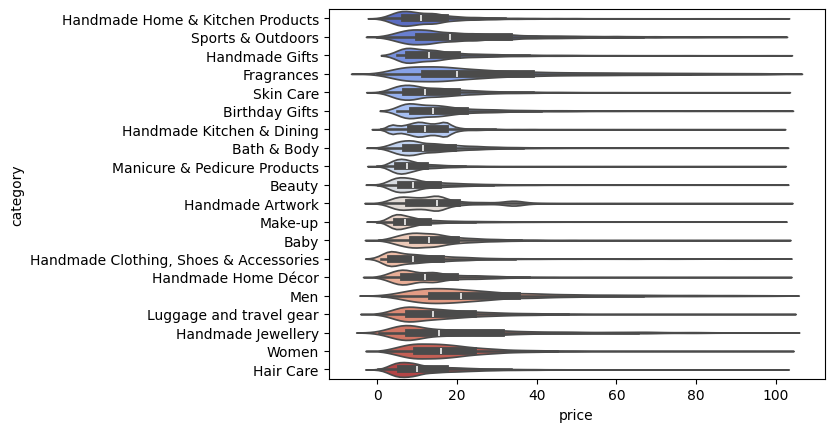

In [22]:
top_20_categories = df['category'].value_counts().head(20).index
df_top_20 = df[df['category'].isin(top_20_categories)]
sns.violinplot(data=df_top_20, x='price', y='category', palette="coolwarm")

In [40]:
df.groupby('category')['price'].median().idxmax()

'Desktop PCs'

la categoria con mayor mediana en precio es Desktop PCs


2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

/var/folders/mc/f5wfnxyx7ln8jvtz9zt_nfk40000gn/T/ipykernel_91854/600934034.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_10, x='category', y='price', palette="coolwarm")


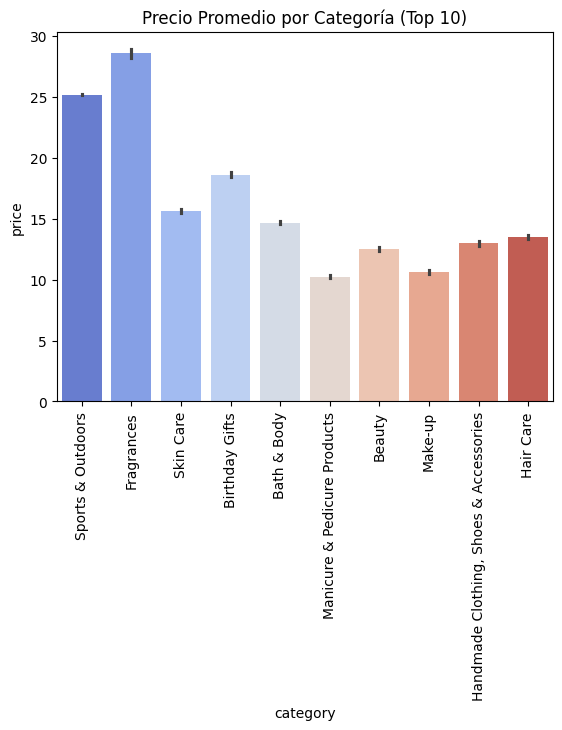

In [38]:
top_10_categories = df['category'].value_counts().head(10).index
df_top_10 = df[df['category'].isin(top_10_categories)]
sns.barplot(data=df_top_10, x='category', y='price', palette="coolwarm")
plt.xticks(rotation=90)
plt.title('Precio Promedio por Categoría (Top 10)')
plt.show()

In [39]:
max_avg_price_category = df.groupby('category')['price'].mean().idxmax()
print(f'Categoría con el precio promedio más alto: {max_avg_price_category}')

Categoría con el precio promedio más alto: Motherboards



3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

/var/folders/mc/f5wfnxyx7ln8jvtz9zt_nfk40000gn/T/ipykernel_91854/3169735686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_10, x='category', y='stars', palette="coolwarm")


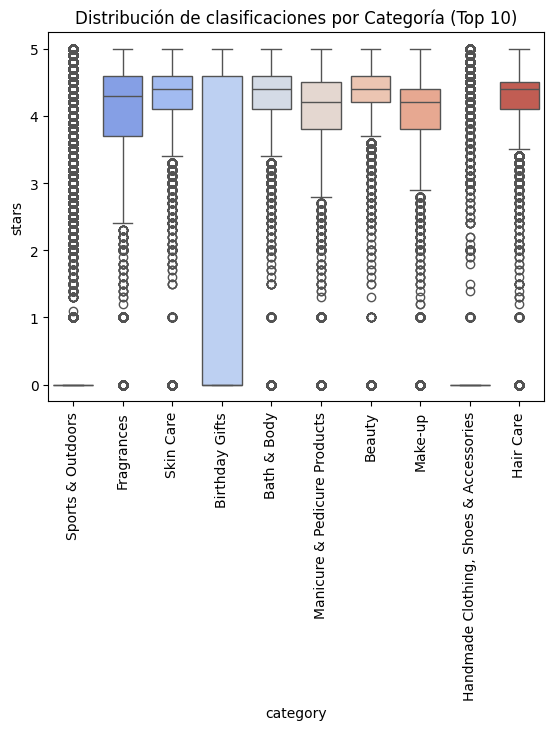

In [42]:
top_10_categories = df['category'].value_counts().head(10).index
df_top_10 = df[df['category'].isin(top_10_categories)]
sns.boxplot(data=df_top_10, x='category', y='stars', palette="coolwarm")
plt.xticks(rotation=90)
plt.title('Distribución de clasificaciones por Categoría (Top 10)')
plt.show()

In [9]:
highest_rated_category = df.groupby('category')['stars'].median().idxmax()
print(f'Categoría con la calificación promedio más alta: {highest_rated_category}')

Categoría con la calificación promedio más alta: Computer Memory


In [45]:
highest_rated_category = df.groupby('category')['stars'].mean()
highest_rated_category.sort_values(ascending=False).head(10)

category
Luxury Food & Drink                    4.547570
Grocery                                4.469061
Laptop Accessories                     4.449600
Health & Personal Care                 4.439649
Arts & Crafts                          4.432663
Office Paper Products                  4.429804
Customers' Most Loved                  4.409956
Water Coolers, Filters & Cartridges    4.363636
USB Hubs                               4.356800
Cables & Accessories                   4.342990
Name: stars, dtype: float64

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?

In [46]:
correlation = df['price'].corr(df['stars'])
correlation

np.float64(-0.07767299878181001)

In [47]:
correlation = df['price'].corr(df['stars'], method='spearman')
correlation

np.float64(-0.06679697280769055)

los valores negatvios en las correlaciones sugieren que cuanto mas alto es el precio peor es la puntuacion que reciben. Pero en este caso el valor tan proximo a cero sugiere que entre ambas variables no hay una correlacion significativa.

2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

<Axes: xlabel='stars', ylabel='price'>

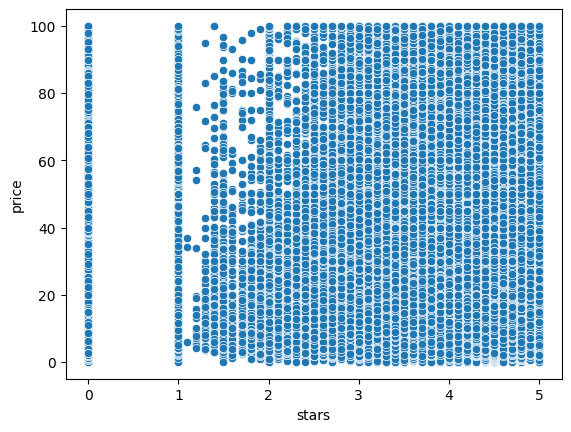

In [50]:
sns.scatterplot(data=df, x='stars', y='price')

realmente el precio y las estrellas no parecen tener una relación clara, lo que se refleja en la baja correlación calculada anteriormente.

In [54]:
df_numerical = df.select_dtypes(include=np.number)
df_numerical.head()

,uid,stars,reviews,price,boughtInLastMonth
0,1,4.7,15308,21.99,0
1,2,4.7,98099,23.99,0
2,3,4.7,15308,21.99,0
3,4,4.7,7205,31.99,0
4,5,4.6,1881,17.99,0


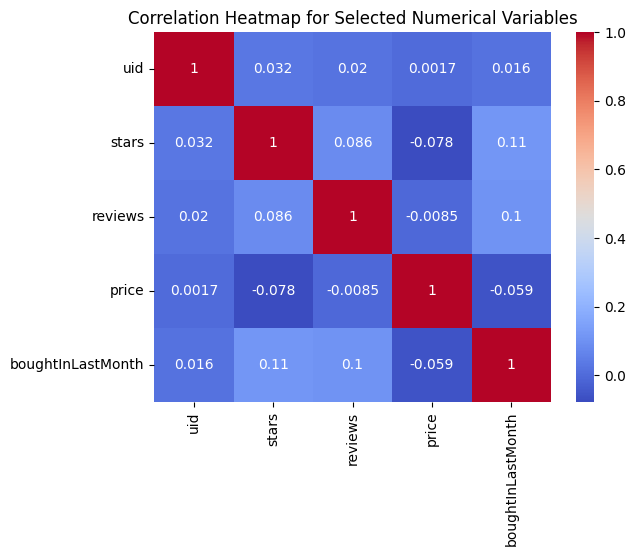

In [ ]:
correlation_matrix = df_numerical.corr()

# Drawing the heatmap for the numerical columns
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

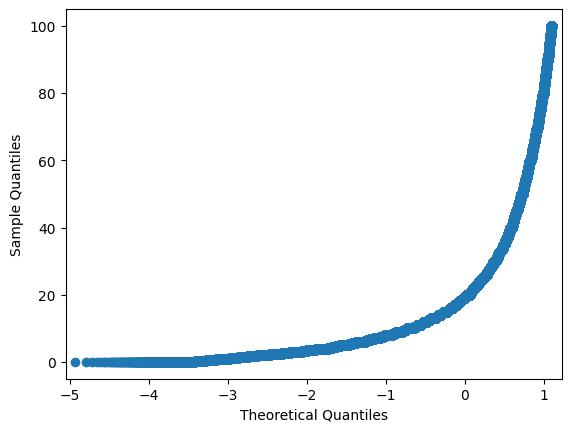

In [ ]:
import statsmodels.api as sm

# Generating a Q-Q plot for 'price' to check if its distribution follows a normal distribution
sm.qqplot(df['price'], line='s');